In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
ar = np.array([3,5,6,2,1,5])

In [ ]:
np.convolve(ar, [1,2,3]) # (3,2,1)

array([ 3, 11, 25, 29, 23, 13, 13, 15])

In [ ]:
from sklearn.datasets import load_digits

In [ ]:
dt = load_digits(n_class=3)

In [ ]:
dt.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [ ]:
#dt.target

In [ ]:
dt.images.shape

(537, 8, 8)

In [ ]:
X = dt.images
Y = dt.target

In [ ]:
X = X.reshape(537,1,8,8)

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam

In [ ]:
X = torch.FloatTensor(X)
Y = torch.LongTensor(Y)

In [ ]:
X.shape

torch.Size([537, 1, 8, 8])

In [ ]:
model = nn.Sequential(
    nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Flatten(),
    nn.Linear(64*2*2, 128),
    nn.ReLU(),
    nn.Linear(128, 3)
)

In [ ]:
loss = nn.CrossEntropyLoss()
opt = Adam(model.parameters(), lr=0.001)

In [ ]:
c=0
for epoch in range(100):
    c=c+1
    opt.zero_grad()
    yp = model(X)
    ls = loss(yp, Y)
    ls.backward()
    opt.step()
    if c%10==0:
      print(ls.item())

0.1955851912498474
0.04194745421409607
0.011235440149903297
0.005000260192900896
0.0026853501331061125
0.0017752257408574224
0.0013085739919915795
0.0009938766015693545
0.0007842793711461127
0.0006314818747341633


In [ ]:
# Prediction on new data

In [ ]:
newx = X[112].reshape(1,1,8,8)

In [ ]:
newx.shape

torch.Size([1, 1, 8, 8])

In [ ]:
Yp = model(newx)

In [ ]:
Yp

tensor([[-3.3233,  4.9742, -3.4670]], grad_fn=<AddmmBackward0>)

In [ ]:
sx = torch.softmax(Yp, dim=1)

In [ ]:
torch.argmax(sx, dim=1)

tensor([1])

**Class Based Model**



In [ ]:
class MyNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
    self.maxm = nn.MaxPool2d(kernel_size=2, stride=2)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()
    self.linear1 = nn.Linear(64*2*2, 128)
    self.linear2 = nn.Linear(128, 3)

  def forward(self, x):
    x = self.conv1(x)
    x = self.relu(x)
    x = self.maxm(x)
    x = self.conv2(x)
    x = self.relu(x)
    x = self.maxm(x)
    x = self.flatten(x)
    x = self.linear1(x)
    x = self.relu(x)
    x = self.linear2(x)
    return x

In [ ]:
class MyNet(nn.Module):
  def __init__(sf):
    super().__init__()
    sf.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
    sf.maxm = nn.MaxPool2d(kernel_size=2, stride=2)
    sf.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
    sf.relu = nn.ReLU()
    sf.flatten = nn.Flatten()
    sf.linear1 = nn.Linear(64*2*2, 128)
    sf.linear2 = nn.Linear(128, 3)

  def forward(sf, x):
    print(x.shape)
    x = sf.conv1(x)
    print(x.shape)
    x = sf.relu(x)
    x = sf.maxm(x)
    x = sf.conv2(x)
    x = sf.relu(x)
    x = sf.maxm(x)
    x = sf.flatten(x)
    x = sf.linear1(x)
    x = sf.relu(x)
    x = sf.linear2(x)
    return x

In [ ]:
mod = MyNet()

In [ ]:
mod(X)

torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])


tensor([[ 0.6020, -0.5551, -0.2006],
        [ 0.6906, -0.2988,  0.1623],
        [ 0.5444, -0.4062,  0.0997],
        ...,
        [ 0.7999, -0.1250,  0.1216],
        [ 0.6068, -0.2345,  0.1623],
        [ 0.8655, -0.6075, -0.2707]], grad_fn=<AddmmBackward0>)

In [ ]:
loss = nn.CrossEntropyLoss()
opt = Adam(mod.parameters(), lr=0.001)

In [ ]:
c=0
for epoch in range(100):
    c=c+1
    opt.zero_grad()
    yp = mod(X)
    ls = loss(yp, Y)
    ls.backward()
    opt.step()
    if c%10==0:
      print(ls.item())

torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
0.2534518539905548
torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 1, 8, 8])
torch.Size([537, 32

**Glimpse of Transfer Learning**

**How to disable some of gradients from getting changed**

In [ ]:
c=0
for p in model.parameters():
  c=c+1
  if c==7:
    p.requires_grad = True
  else:
    p.requires_grad = False

In [ ]:
model

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=256, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=3, bias=True)
)

In [ ]:
#model(X)

In [ ]:
print(ls.item())

0.0004147932631894946


In [ ]:
print(ls)


tensor(0.0004, grad_fn=<NllLossBackward0>)


In [ ]:
ls = torch.tensor([5, 10, 15])

print(ls[0])        # ✅ tensor(5)
print(ls[0].shape) # ✅ torch.Size([])

tensor(5)
torch.Size([])


In [ ]:
ls = []

for p in model.parameters():
    if p.requires_grad:
        ls.append(p.shape)

for s in ls:
    print(s)

torch.Size([3, 128])


In [ ]:
print(model)

Sequential(
  (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=256, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=3, bias=True)
)


In [ ]:
for name, p in model.named_parameters():
    print(p.shape)

torch.Size([32, 1, 3, 3])
torch.Size([32])
torch.Size([64, 32, 3, 3])
torch.Size([64])
torch.Size([128, 256])
torch.Size([128])
torch.Size([3, 128])
torch.Size([3])


--2026-03-26 07:57:17--  https://i.stack.imgur.com/lJ40z.png
Resolving i.stack.imgur.com (i.stack.imgur.com)... 198.252.206.17
Connecting to i.stack.imgur.com (i.stack.imgur.com)|198.252.206.17|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://i.sstatic.net/lJ40z.png [following]
--2026-03-26 07:57:17--  https://i.sstatic.net/lJ40z.png
Resolving i.sstatic.net (i.sstatic.net)... 198.252.206.17
Connecting to i.sstatic.net (i.sstatic.net)|198.252.206.17|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-03-26 07:57:17 ERROR 404: Not Found.

Original Image Shape: (180, 180, 3)
Grayscale Image Shape: (180, 180)
Resized Image Shape: (8, 8)
Processed Input Tensor Shape: torch.Size([1, 1, 8, 8])


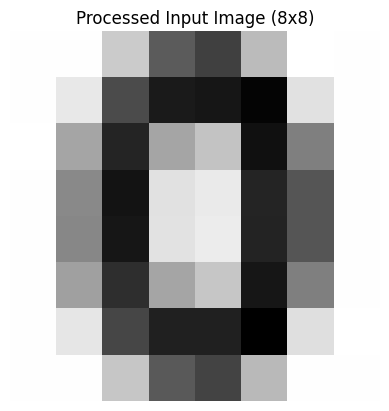

In [ ]:
import cv2
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

!wget -O example_digit.png https://i.stack.imgur.com/lJ40z.png
external_image_orig = cv2.imread('zero1.jpg')

if external_image_orig is None:
    print("Error: Image not found or could not be loaded.")
else:

    gray_image = cv2.cvtColor(external_image_orig, cv2.COLOR_BGR2GRAY)
    resized_image = cv2.resize(gray_image, (8, 8), interpolation=cv2.INTER_AREA)
    max_pixel_val = resized_image.max()
    if max_pixel_val > 0: # Avoid division by zero if image is all black
        processed_image = resized_image / (max_pixel_val / 16.0) # Scale to 0-16 range
    else:
        processed_image = resized_image.astype(float)

    input_tensor = torch.FloatTensor(processed_image).unsqueeze(0).unsqueeze(0)

    print("Original Image Shape:", external_image_orig.shape)
    print("Grayscale Image Shape:", gray_image.shape)
    print("Resized Image Shape:", resized_image.shape)
    print("Processed Input Tensor Shape:", input_tensor.shape)

    plt.imshow(processed_image, cmap='gray')
    plt.title('Processed Input Image (8x8)')
    plt.axis('off')
    plt.show()

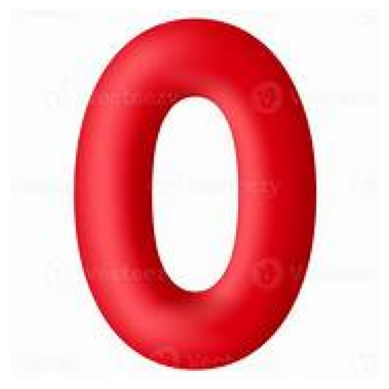

In [ ]:
import matplotlib.pyplot as plt
import cv2

if 'external_image_orig' in locals() and external_image_orig is not None:
    # OpenCV loads images in BGR format, matplotlib expects RGB
    image_rgb = cv2.cvtColor(external_image_orig, cv2.COLOR_BGR2RGB)
    plt.imshow(image_rgb)

    plt.axis('off')
    plt.show()
else:
    print("The 'external_image_orig' variable is not available or is empty. Please ensure the image was loaded correctly in the previous steps.")

In [ ]:
if 'input_tensor' in locals() and input_tensor is not None:
    # Ensure the model is in evaluation mode
    mod_batched.eval()

    # Make a prediction with the trained model (mod_batched)
    with torch.no_grad(): # Disable gradient calculations for inference
        output = mod_batched(input_tensor)

    # Apply softmax to get probabilities
    probabilities = torch.softmax(output, dim=1)

    # Get the predicted class (index with highest probability)
    predicted_class = torch.argmax(probabilities, dim=1).item()

    print("Model Output (logits):", output)
    print("Probabilities:", probabilities)
    print("Predicted Class:", predicted_class)

    # Optionally, get the target name if available
    if 'dt' in globals() and 'target_names' in dt:
        target_names = dt.target_names
        if predicted_class < len(target_names):
            print(f"Predicted Digit: {target_names[predicted_class]}")
        else:
            print("Predicted class index is out of bounds for target_names.")
    else:
        print("Target names not available in 'dt' object.")
else:
    print("No input_tensor was created. Please ensure the image loading and processing steps were successful.")

torch.Size([1, 1, 8, 8])
torch.Size([1, 32, 8, 8])
Model Output (logits): tensor([[ 0.8546, -0.7663,  1.0627]])
Probabilities: tensor([[0.4117, 0.0814, 0.5069]])
Predicted Class: 2
Predicted Digit: 2


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# Create a TensorDataset
dataset = TensorDataset(X, Y)

# Create a DataLoader
batch_size = 64 # You can adjust this batch size
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Number of samples: {len(dataset)}")
print(f"Batch size: {batch_size}")
print(f"Number of batches: {len(dataloader)}")

Number of samples: 537
Batch size: 64
Number of batches: 9


In [ ]:
mod_batched = MyNet() # Initialize a new model for batched training
loss_batched = nn.CrossEntropyLoss()
opt_batched = Adam(mod_batched.parameters(), lr=0.001)

c_batched = 0
num_epochs = 100

for epoch in range(num_epochs):
    for batch_idx, (data, target) in enumerate(dataloader):
        opt_batched.zero_grad()
        yp_batched = mod_batched(data)
        ls_batched = loss_batched(yp_batched, target)
        ls_batched.backward()
        opt_batched.step()

    c_batched += 1
    if c_batched % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {ls_batched.item():.4f}")

torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 8, 8])
torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 8, 8])
torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 8, 8])
torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 8, 8])
torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 8, 8])
torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 8, 8])
torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 8, 8])
torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 8, 8])
torch.Size([25, 1, 8, 8])
torch.Size([25, 32, 8, 8])
torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 8, 8])
torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 8, 8])
torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 8, 8])
torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 8, 8])
torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 8, 8])
torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 8, 8])
torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 8, 8])
torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 8, 8])
torch.Size([25, 1, 8, 8])
torch.Size([25, 32, 8, 8])
torch.Size([64, 1, 8, 8])
torch.Size([64, 32, 

In [ ]:
import cv2

In [ ]:

ar = cv2.imread('zero1.jpg')



In [ ]:
ar.shape

(180, 180, 3)

In [ ]:
grar = cv2.cvtColor(ar, cv2.COLOR_BGR2GRAY)

In [ ]:
rszar = cv2.resize(grar, (8, 8))

In [ ]:
far = rszar.reshape(1, 64)

In [ ]:
far

array([[254, 254, 250,  88,  65, 251, 254, 253, 254, 252, 134,  87,  82,
         61, 253, 254, 254, 240,  97, 248, 251,  71, 232, 254, 253,  92,
         79, 252, 254,  97,  55, 252, 254,  89,  82, 253, 253,  96,  53,
        254, 254, 242, 112, 248, 252,  93, 234, 255, 253, 252, 130,  90,
         96,  62, 253, 254, 252, 252, 251,  88,  67, 251, 253, 253]],
      dtype=uint8)

In [ ]:
fimg = torch.FloatTensor(far)

In [ ]:
fimg_reshaped = torch.FloatTensor(rszar).unsqueeze(0).unsqueeze(0)
Yp = model(fimg_reshaped)
print(Yp)

tensor([[ -9.8341, -32.2649,  -5.6283]], grad_fn=<AddmmBackward0>)


In [ ]:
sx = torch.softmax(Yp, dim=1)
predicted_class = torch.argmax(sx, dim=1).item()

print("Probabilities:", sx)
print("Predicted Class:", predicted_class)

# Optionally, get the target name if available
if 'dt' in globals() and 'target_names' in dt:
    target_names = dt.target_names
    if predicted_class < len(target_names):
        print(f"Predicted Digit: {target_names[predicted_class]}")
    else:
        print("Predicted class index is out of bounds for target_names.")
else:
    print("Target names not available in 'dt' object.")

Probabilities: tensor([[1.4690e-02, 2.6635e-12, 9.8531e-01]], grad_fn=<SoftmaxBackward0>)
Predicted Class: 2
Predicted Digit: 2


In [ ]:
fimg_reshaped = torch.FloatTensor(rszar).unsqueeze(0).unsqueeze(0)
sfx = torch.softmax(model(fimg_reshaped), dim=1)

In [ ]:
torch.argmax(sfx, dim=1)

tensor([2])

# **Using Batches**

In [ ]:
model.train()
c=0
for epoch in range(100):
    c=c+1
    epoch_loss = 0.0
    for batch_X, batch_Y in dataloader:
        opt.zero_grad()
        yp = model(batch_X)
        ls = loss(yp, batch_Y)
        ls.backward()
        opt.step()
        epoch_loss += ls.item()

    if c%10==0:
      print(epoch_loss)

0.005330383370164782
0.005310610693413764
0.00584829063154757
0.005352968670194969
0.005287251187837683
0.006023797322995961
0.0054113576479721814
0.005812627394334413
0.005429684650152922
0.005372642452130094


# **Class Based Models**

In [ ]:
import torch
import torch.nn as nn

In [ ]:
#class Birds:
 # def __init__(self,name):
   # print(name)


In [ ]:
#ob = Birds("cat")

cat


In [ ]:
class Birds(nn.Module):
  def __init__(self, name=None):
    super().__init__()
    if name:
      print(name)
    print("how are you")

  def forward(self):
    print("where are you")

In [ ]:
ob = Birds()

how are you


In [ ]:
ob()

where are you


In [ ]:
class MyNet(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
    self.maxm = nn.MaxPool2d(kernel_size=2, stride=2)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
    self.relu = nn.ReLU()
    self.flatten = nn.Flatten()
    self.linear1 = nn.Linear(64*2*2, 128)
    self.linear2 = nn.Linear(128, 3)

  def forward(self, x):
    print(x.shape)
    x = self.conv1(x)
    print(x.shape)
    x = self.relu(x)
    print(x.shape)
    x = self.maxm(x)
    print(x.shape)
    x = self.conv2(x)
    print(x.shape)
    x = self.relu(x)
    print(x.shape)
    x = self.maxm(x)
    print(x.shape)
    x = self.flatten(x)
    print(x.shape)
    x = self.linear1(x)
    print(x.shape)
    x = self.relu(x)
    print(x.shape)
    x = self.linear2(x)
    print(x.shape)
    return x

mod = MyNet()
print("Model output:", mod(X))

torch.Size([537, 1, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 32, 8, 8])
torch.Size([537, 32, 4, 4])
torch.Size([537, 64, 4, 4])
torch.Size([537, 64, 4, 4])
torch.Size([537, 64, 2, 2])
torch.Size([537, 256])
torch.Size([537, 128])
torch.Size([537, 128])
torch.Size([537, 3])
Model output: tensor([[ 0.2004, -0.6393,  0.1782],
        [ 0.0279, -0.4003, -0.3323],
        [-0.0168, -0.4900,  0.1462],
        ...,
        [ 0.2864, -0.1670,  0.2643],
        [ 0.3142, -0.0379,  0.2410],
        [ 0.2709, -0.5161,  0.3372]], grad_fn=<AddmmBackward0>)


In [ ]:
mod = MyNet()

In [ ]:

loss = nn.CrossEntropyLoss()
opt = Adam(mod.parameters(), lr=0.001)

In [ ]:

c=0
for epoch in range(100):
    c=c+1
    opt.zero_grad()
    yp = mod(X)
    ls = loss(yp, Y)
    ls.backward()
    opt.step()
    if c%10==0:
      print(ls.item())

0.1742929369211197
0.02421889267861843
0.005779348313808441
0.002362325554713607
0.0012139257742092013
0.0008142731385305524
0.0006392754730768502
0.000529611308593303
0.00044879381312057376
0.000385832303436473


# **Glimpse of Transfer Learning**
**How to disable some of gradients from getting changed**

In [ ]:
c=0
for p in model.parameters():
  c=c+1
  if c==7:
    p.requires_grad = True
  else:
    p.requires_grad = False